# Investigating parameters effects on Sensitivity of the OGGM Mass Balance and Runoff Models

In this notebook we will explore the sensitivity of OGGM's mass-balance and runoff models using SAFE. We will focus on the three parameters: melt factor, precipitation factor and temperature bias.

We will start by applying one-at-a-time sensitivity analysis to get a feel for how much each parameter affects the model and output. We will then consider the uncertainty of these sensitivities and work to quantify them.

## Sensitivity Analysis with the OGGM Mass Balance Model

We will apply sensitivity analysis in the following order to investigate our model behaviour:

1. **One-at-a-time**: We will apply one-at-a-time analysis , in which we change one parameter at a time and see how the mass balance changes in accordance. To show this, we will plot an interactive mass balance time series with toggles, where the parameter values can be changed within their default boundaries.
2. **Global sensitivity analysis**: Here we will use AAT sampling to randomly sample a combination of the 3 parameters and investigate the sensitivity in the following ways
    a. Qualitative - scatter plots
    b. Quantitative - RSA and bootstrapping

This will be applied first to the mass balance model in the OGGM, and then to the runoff model in the OGGM.

First we install the packages we require from both OGGM and SAFE.

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import scipy.stats as st

import oggm
from oggm import cfg, utils, workflow
from oggm.core import massbalance
from oggm.utils._funcs import rmsd
from oggm import tasks
from oggm.core.massbalance import MultipleFlowlineMassBalance

# Install python package for interactive visualisation and import required functions:
%pip install -q ipywidgets
from ipywidgets import interact, fixed

# Install SAFE package and import required functions
%pip install SAFEpython

import xarray as xr
import safepython.PAWN as PAWN # Module to calculate PAWN sensitivity indices
import safepython.RSA_thres as RSA_tr # Module that implements RSA
from safepython.model_execution import model_execution # Module to execute the model
from safepython.sampling import AAT_sampling # Functions to perform the input sampling
from safepython.util import aggregate_boot # Functions to perform bootstrapping


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Now prepare to load the glacier dierectories from the OGGM.

In [2]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['use_multiprocessing'] = True  # To speed up sensitivity analysis runs
cfg.PARAMS['mp_processes'] = -1  # Use all available cores
oggm.cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

2026-02-16 09:18:39: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-02-16 09:18:39: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-02-16 09:18:39: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-02-16 09:18:40: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2026-02-16 09:18:40: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-02-16 09:18:40: oggm.cfg: Multiprocessing switched ON after user settings.
2026-02-16 09:18:40: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-02-16 09:18:40: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [3]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2026-02-16 09:18:43: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-02-16 09:18:43: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


Creating the dataframe and adding the observed mass balance.

In [ ]:
# Get the observed mass balance and set up dataframe

mbdf = gdir_hef.get_ref_mb_data().loc[1979:2019] # WGMS data for HEF
mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[1979:2019]['ANNUAL_BALANCE'] # In-situ mass balance for comparison


# Step 1 - The OGGM Runner, to produce mass balance and runoff simulations with dynamic spinup and run with hydro

We have loaded all required packages, so now we need to create a runner for the OGGM. To do this, we will set the 3 mass balance parameters to some tentative values, run the model and plot the resulting runoff timeseries. We can then change the parameter values one-at-a-time and look at how this changes the model predictions.

This runner will produce two timeseries:
1. The mass balance
2. The runoff

The method will default to producing the two timeseries for mass balance and runoff, for the maximum amount of information derived from the simulation. If the do_hydro flag is set to False, only the mass balance timeseries is produced.

In [ ]:
def oggm_sim(sample_row, gdir, do_hydro=True, years=range(1979,2020)): 
    '''
    Reads in the parameters (melt_f, prcp_fac and temp_bias) set in the inputs, and runs the OGGM processes to 
    produce either a time series for the annual specific mass balance, or for the annual runoff.

    Parameters:
    -------------
    sample_row: Tuple
        The parameters we are feeding in (likely from our randomly generated samples). This is a tuple of
        (melt_f, prcp_fac, temp_bias).
    gdir: GlacierDirectory
        The glacier directory.
    do_hydro=False: bool
        A flag to indicate if the user wishes to produce a regular mass balance timeseries, or requires to execute the
        OGGM task, run_with_hydro, which produces a timeseries of the runoff.
    years: range(int,int)
        The years we wish to produce a timeseries for.

    Returns:
    -------------
    np.ndarray
        Specific mass balance (units: mm w.e. yr-1).
        OR Runoff (units: Mt w.e. yr-1).

    '''
    mbdf = gdir.get_ref_mb_data().loc[years] # WGMS data for HEF
    
    # Set the parameter values
    melt_f, prcp_fac, temp_bias = sample_row

    # Hydrological model workflow steps before running with hydro
    cfg.PARAMS['evolution_model'] = 'FluxBased'
    cfg.PARAMS['store_model_geometry'] = True

    mb = MultipleFlowlineMassBalance(
        gdir,
        mb_model_class=massbalance.MonthlyTIModel,
        melt_f=float(melt_f),
        prcp_fac=float(prcp_fac),
        temp_bias=float(temp_bias),
        check_calib_params=False,
        )
    
    fls = gdir.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mb.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance  

    if not do_hydro: # If the do_hydro flag is set to false, just return the mass balance
        return np.array(mbdf['mod_mb']), None

    else: # If the do_hydro flag is set to true, generate the hydrological data and calculate the runoff
        gdir.settings['error_when_glacier_reaches_boundaries'] = False # TODO- When more realistic, I assume we will not need this?

        # file identifier where the model output is saved
        # Create unique file identifier based on parameters
        file_id = f'_hydro_mf{melt_f:.2f}_pf{prcp_fac:.2f}_tb{temp_bias:.2f}'

        cfg.PARAMS['store_model_geometry'] = True  # add additional outputs for the maps below
        cfg.PARAMS['evolution_model'] = 'FluxBased'
        
        f = gdir.get_filepath('model_geometry', filesuffix='_spinup')
        if os.path.exists(f):
            os.remove(f)

        workflow.execute_entity_task(
            tasks.run_dynamic_spinup,
            [gdir],
            settings_filesuffix='_spinup',
            mb_model_historical=mb, # Use the mass balance model for the historical part
            spinup_start_yr=1979,
            spinup_period=10,
            min_spinup_period=5,
            output_filesuffix='_spinup'
        )

        with xr.open_dataset(gdir.get_filepath('model_geometry', filesuffix='_spinup')) as ds:
            if ds.time.values[0] != 1979.0:
                print("VALUES", melt_f, prcp_fac, temp_bias)
        
        # 2. Run with hydro
        workflow.execute_entity_task(
            tasks.run_with_hydro,
            [gdir],
            run_task=tasks.run_from_climate_data,
            ys=1979, # The simulation start year
            min_ys=1979, # For the run from climate data, to ensure we have data from 1979
            init_model_filesuffix='_spinup',
            init_model_yr=1979,
            ref_geometry_filesuffix='_spinup', # use the spinup geometry
            ref_area_yr=2004,
            mb_model=mb, # The modified MB model
            store_monthly_hydro=True,
            output_filesuffix=file_id,
        )

        with xr.open_dataset(gdir.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
            # The last step of hydrological output is NaN (we can't compute it for this year)
            ds = ds.isel(time=slice(0, -1)).load()
            
        # These summed variabels give the total runoff from the glacier
        runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']

        df_annual = ds[runoff_vars].to_dataframe()
        df_runoff = df_annual[runoff_vars].clip(0) * 1e-9

        # Convert them to megatonnes (instead of kg)
        runoff = df_runoff.sum(axis=1).to_numpy()

        return np.array(mbdf['mod_mb']), runoff

The below method calculates the fit to data metrics for the mass balance. For the mass balance timeseries we have observational data, we can compare our simulations to the data to get an idea of how well our simulations fit to the observed values that we have.

In [6]:
def fit_to_data_metric_calculator(sim, gdir, years=range(1979,2020)):
    '''
    Calculates the fit-to-data metrics from the Mass Balance data, on which we can run the sensitivity analysis.
    This is only used for the mass balance, where we can access a sufficient amount of data to calculate these metrics.

    Parameters:
    ------------

    sim: np.array
        The mass balance time series generated from the oggm_sim method, when the output is the mass balance time series.

    gdir: GlacierDirectory
        The glacier directory.

    years: range(int,int)
        The years we are using data from.

    Return:
    ------------

    YY: np.array
        An array containing the values of:
            - The difference in mass balance between the observed and simulated means.
            - The difference in mass balance between the observed and simulated standard deviations.
            - The RMSD between the simulated mass balance and the observed mass balance annual values.
    '''
    
    # Get the observed mass balance and set up dataframe
    mbdf = gdir.get_ref_mb_data().loc[years] # WGMS data for HEF
    mbdf['in_situ_mb'] = gdir.get_ref_mb_data().loc[years]['ANNUAL_BALANCE'] # In-situ mass balance for comparison

    # Calculates the goodness-of-fit metrics for all model simulations compared to the in-situ mass balance
    YY = np.zeros((sim.shape[0], 3))

    for i in range(sim.shape[0]):
        # Calculate the goodness-of-fit metrics from the simulated mass balance and the in-situ mass balance
        YY[i, 0] = np.array(sim[i].mean() - mbdf['in_situ_mb'].mean()) # Calculate mean difference
        YY[i, 1] = np.array(sim[i].std() - mbdf['in_situ_mb'].std()) # Calculate standard deviation difference
        YY[i, 2] = np.array(rmsd(sim[i], mbdf['in_situ_mb'])) # Calculate RMSD

    return YY

The below method calculates the output metrics we will be using to understand the output of our hydrological simulations and our runoff timeseries. We currently do not have any observed data and so we are unsure of the values to expect, but we can still look into the mean and standard deviation, and use these in our sensitivity analysis.

Using the mean and standard deviation can give us a good picture of the data we have generated.

In [7]:
def hydro_output_metric_calculator(runoff):
    '''
    Calculates the output metrics for runoff, the mean and the standard deviation. 

    This is currently only used for calculting the mean and standard deviation of the runoff
    but can be added to in the future.

    Parameters:
    ------------

    runoff: np.array
        The runoff time series generated from the oggm_sim method, when the output is the runoff time series.

    Return:
    ------------

    YY: np.array
        An array containing the values of:
            - The annual runoff mean.
            - The annual runoff standard deviation.
    '''
    YY = np.nan * np.ones((len(runoff), 2))

    for i, x in enumerate(runoff):
        YY[i,0] = np.mean(x)
        YY[i,1] = np.std(x)

    return YY

We will now plot our results, the parameter values can be changed one-at-a-time via a toggle on the graph below.

In [ ]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series
def oat_function(gdir, years, melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    '''  
    Calls the oggm_sim function and plots each mass balance time series with an interactive plot.

    Parameters:
    ------------
    gdir: GlacierDirectory
        The glacier directory.
    years: range
        The years we are investigating.
    melt_f = 5.0: float
        The value of the melt factor you want to use, here the unit
        is kg m-2 day-1 K-1. Defaults to the default value.
    prcp_fac = 3.4: float
        The value of the precipitation factor. Defaults to the
        default value.
    temp_bias : float
        The value of the temperature bias. Defaults to the
        default value.


    Returns:
    ------------
    An interactive plot displaying the mass balance time series of the glacier with the given parameters.
    '''
    # Create parameter array
    param = np.array([melt_f, prcp_fac, temp_bias])
    
    # Get the observed mass balance and set up dataframe
    mbdf = gdir.get_ref_mb_data().loc[years] # WGMS data for HEF
    mbdf['in_situ_mb'] = gdir.get_ref_mb_data().loc[years]['ANNUAL_BALANCE'] # In-situ mass balance for comparison

    # Run the model with the given parameters, here we are interested in the modelled mass balance time series
    mb, runoff = oggm_sim(param, gdir, do_hydro=False, years=years)

    # Plot the results
    plt.figure(figsize=[15,3])
    plt.plot(mbdf['in_situ_mb'].index, mb, label='sim', color='k')
    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[years]['ANNUAL_BALANCE']
    plt.plot(mbdf['in_situ_mb'], color=[0.7,0.7,0.7], label='obs')
    plt.ylabel('Specific mass balance (mm w.e.)')
    plt.xlabel('Year')
    plt.legend()
    plt.show();

# Create interactive plot, the toggles will change the parameter values 
interact(oat_function,
         gdir = fixed(gdir_hef),
         run_with_hydro = fixed(False),
         years = fixed(range(1979,2020)),
         melt_f = (1.5, 17.0, 0.1),
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-15.0, 15.0, 0.1));

interactive(children=(FloatSlider(value=5.0, description='melt_f', max=17.0, min=1.5), FloatSlider(value=3.4, …

The above graph shows the effects that moving each of the parameters has to the mass balance time series.

# GSA - Global Sensitvity Analysis

For our Global Sensitivity Analysis here we will be initially using Regional Sensitivity Analysis (RSA) and exploring PAWN in the SAFE Toolbox later on. More information on the RSA method can be seen in [Pianosi et al., 2016](https://www.sciencedirect.com/science/article/pii/S1364815216300287?fr=RR-2&ref=pdf_download&rr=9c07930109fe6535#bib67).

RSA is also called Monte Carlo filtering, here we split input samples depending on whether the associated output is above or below a prescribed threshold. Then the two input sets are compared to gain insight on the model behaviour and mapping.

RSA has been widely used in applications where the model output is an objective function (i.e. a measure of the model accuracy against observations) and splitting the criterion reflects the acheivement of a minimum requirement of model performance. This works well for our Mass-Balance sensitivity in the OGGM since we have access to WGMS data from observations of the Mass-Balance. We will be comparing the fit-to-data metrics of: the difference in mean values, the difference in standard deviation values and the RMSD. In an ideal scenario, we will be aiming to get this as close to 0 as possible and so we can use this as our RSA threshold. 

We will be using AAT Sampling from SAFE to perform global sampling. This method will be creating Monte Carlo Simulations, we will start by plotting the mass balance time series resulting from the Monte Carlo simulations and analyse the results.

### Running Monte Carlo Simulations

We run Monte Carlo Simulations with AAT Sampling from SAFE, we then execute our simulation with only mass balance to view the mass balance.

In [22]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)

distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 0.1, -2.0]) # Minimum values for each parameter
x_max = np.array([10.0, 10.0, 2.0]) # Maximum values for each parameter

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
    
samp_strat = 'lhs' 

N = 1000  # Number of samples
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

sim = model_execution(oggm_sim, X, gdir_hef, False) # Execute the model for all samples

We had some behaviour that needs investigation: the RMSD and mean appeared to have a linear relationship.

In [ ]:
# The mean and RMSD appeared to have a linear relationship before, this was likely due to the massively large range we were using for temperature bias before.
# Investigate with this part here - the RMSD and its decomposition.
import numpy as np

x = np.asarray(sim[0])
y = np.asarray(mbdf['in_situ_mb'])

rmsd = np.sqrt(np.mean((x - y)**2)) # Coded calculation of the RMSD that we would expect
bias = np.mean(x) - np.mean(y)

# Stats
sx = np.std(x, ddof=1)
sy = np.std(y, ddof=1)
r  = np.corrcoef(x, y)[0,1]

# Decomposition pieces
variance_term = sx**2 + sy**2 - 2*sx*sy*r
lhs = rmsd**2
rhs = bias**2 + variance_term

print(f"RMSD: {rmsd:.6f}")
print(f"|Bias|: {abs(bias):.6f}")
print(f"sx, sy, r: {sx:.6f}, {sy:.6f}, {r:.6f}")
print(f"RMSD^2 vs bias^2 + variance term: {lhs:.6f} vs {rhs:.6f}")

# The bias is the largest contributor to the RMSD in this case, indicating that the model systematically
# over or underestimates the mass balance compared to observations. Therefore leading to the linear relationship between the mean and the RMSD.


RMSD: 815.161931
|Bias|: 740.192382
sx, sy, r: 531.076776, 525.141601, 0.785787
RMSE^2 vs bias^2 + variance term: 664488.973646 vs 667404.078940


After investigation, we can see that RMSD and the bias values are similar values.

- $RMSD^2 = bias^2 + variance$, when the bias is large, the RMSD increases with it.
- In our above investigation the bias term is 740, which is quite large. This is around 80% which is a large proportion of the RMSD term. Therefore around 80% of the magnitude of the RMSD comes from the bias term alone (differences in the means).
- The variation in our dataset is relatively low, the main change in our timeseries is the shift in magnitude while maintaining a similar shape for the timeseries.
- Therefore this results in the relationship appearing as almost linear.

In [24]:
YY = fit_to_data_metric_calculator(sim, gdir_hef) # Calculate the output metrics for all simulations

Plotting the Monte Carlo simulation results and comparison with the observed data.

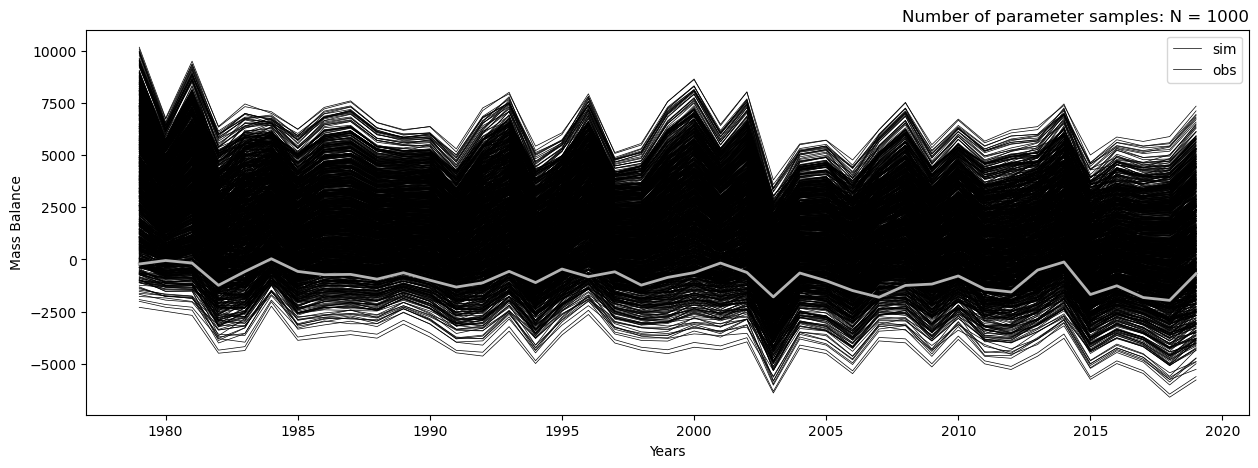

In [25]:
# Plot Monte Carlo (MC) simulations results and compare with data:
plt.figure(figsize=[15,5])
plt.plot(mbdf['in_situ_mb'].index.values, np.transpose(sim), 'k', linewidth = 0.5)
plt.plot(mbdf['in_situ_mb'], color=[0.7,0.7,0.7], linewidth=2)
plt.ylabel('Mass Balance'); plt.xlabel('Years')
plt.legend(['sim', 'obs'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()

We can see from the samples that the mass balance is greatly affected by altering the parameters between their given ranges. The lower mass balances seem to be more sparse, with a more significant clustering towards the higher mass-balances. The observed mass-balance is closer towards the higher mass-balance end of the spectrum, towards 0. 

### Scatter plot of the fit-to-data metrics

We will now plot a scatter plot of the fit-to-data metrics, this will show us the relationship between the metrics created from our Monte Carlo simulations.

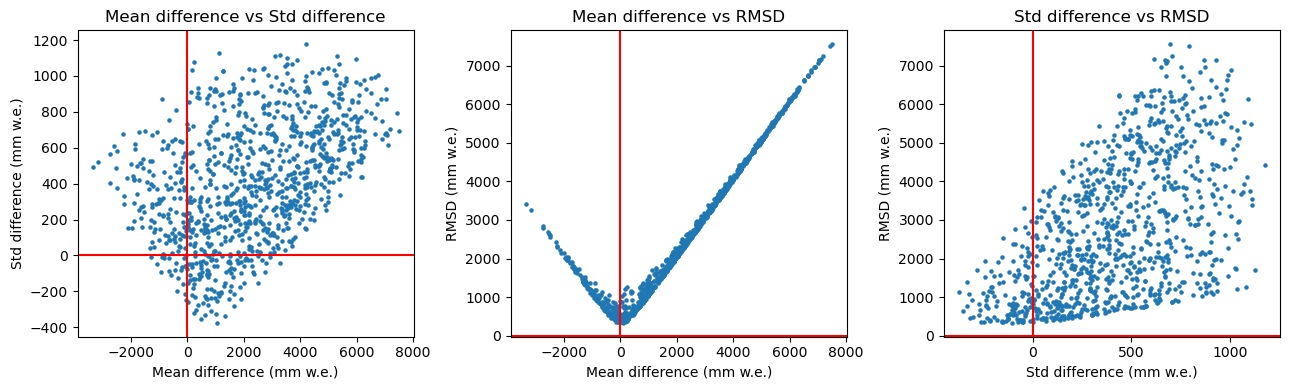

In [ ]:
plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(YY[:,0], YY[:,1], s=5), plt.title('Mean difference vs Std difference'), plt.xlabel('Mean difference (mm w.e.)'), plt.ylabel('Std difference (mm w.e.)'),
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,2), plt.scatter(YY[:,0], YY[:,2], s=5), plt.title('Mean difference vs RMSD'), plt.xlabel('Mean difference (mm w.e.)'), plt.ylabel('RMSD (mm w.e.)')
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,3), plt.scatter(YY[:,1], YY[:,2], s=5), plt.title('Std difference vs RMSD'), plt.xlabel('Std difference (mm w.e.)'), plt.ylabel('RMSD (mm w.e.)')
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.tight_layout()
plt.show()

# The red lines show the target of having zero differences in the mean, standard deviation and RMSD.

The red lines show the target values of our differences, ideally we would want our differences to be 0 and to match the observations as closely as possible.

It can be seen here that all of our fit-to-data metrics are correlated.

## Scatter plot for the parameters against the fit-to-data metrics

Now we can plot the scatter plots for each parameter against each metric, this will help visualise the sensitivities for the mass balance.

In [29]:
YY_Labels = ['Mean Difference', 'Std Difference', 'RMSD']

def scatter_function(metric='Mean Difference'):
    if metric == 'Mean Difference':
        j = 0
    elif metric == 'Std Difference':
        j = 1  
    elif metric == 'RMSD':
        j = 2
    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        plt.plot(X[:, i], YY[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        if i == 0:
            plt.ylabel(YY_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       
    plt.show()

interact(scatter_function,  metric = YY_Labels);

interactive(children=(Dropdown(description='metric', options=('Mean Difference', 'Std Difference', 'RMSD'), va…

### Distribution of the model outputs

Now looking at the distribution of the model outputs, here this is the goodness-of-fit parameters.

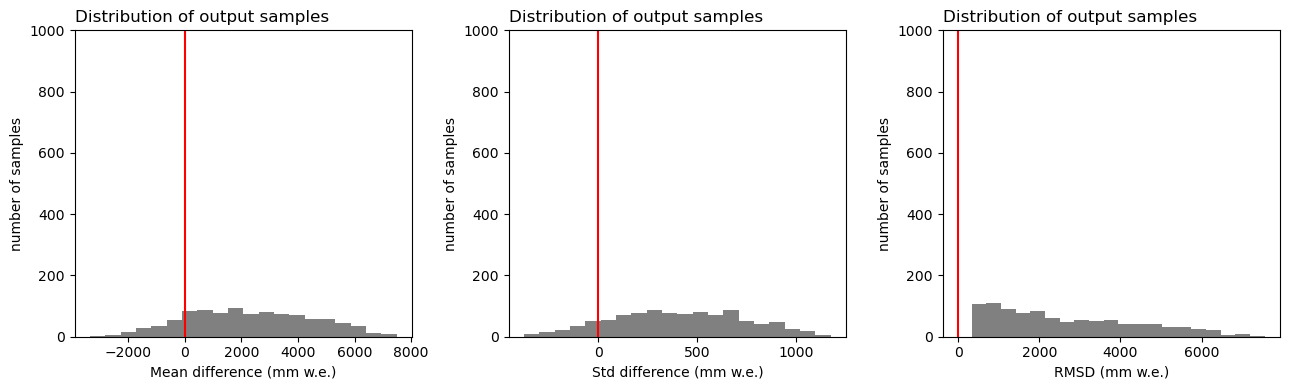

In [30]:
Y_Labels = ['Mean difference (mm w.e.)', 'Std difference (mm w.e.)', 'RMSD (mm w.e.)', 'Mean & Std difference jointly']

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,0], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[0])
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,1], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[1])
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,3), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,2], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[2])
plt.gca().locator_params(axis='x', nbins=6)

plt.tight_layout()

Looking at our distributions of the output samples, the distributions are as follows:
1. Mean difference: Skewed distribition with a long tail (negative skew)
2. Std difference: Normal distribution
3. RMSD: Skewed distribution with a long tail (positive skew)

# Calculating the Sensitivity Indices

Now we use the input-output samples generated in the previous step to calculate sensitivity indices using **Regional Sensitivity Analysis**. Calculating 3 sets of indices, each measuring the relative importance of the 3 input parameters.

Since we have some fit-to-data metrics, we know that ideally the differences between the simulated and observed means, standard deviation and the RMSD would be as close to 0 as possible. Therefore for a ranking of the sensitivites of our parameters against the outputs, we can set the threshold to be 0 (or as close to 0 as the dataset permits).

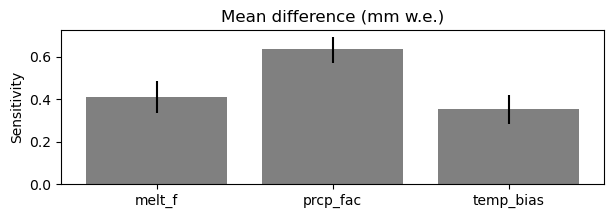

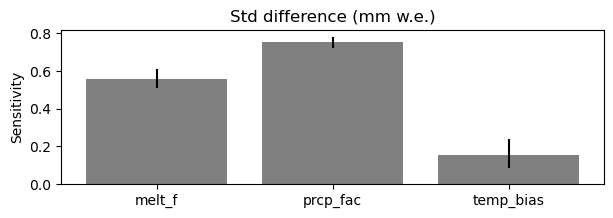

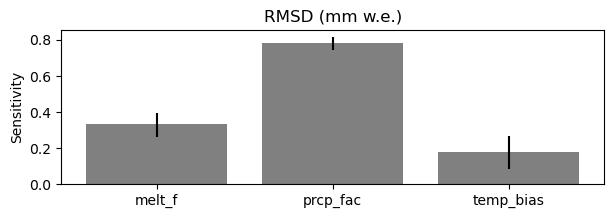

In [31]:
Nboot = 50 # Number of resamples used for bootstrapping

for i in range(3):
    if i==0:
        Y=YY[:,0]
        target=0
    if i==1:
        Y=YY[:,1]
        target=0
    if i==2:
        Y = YY[:,2]
        target = 500 # RMSD cannot be zero here? Minimum working number is around 550, minimum observed value is around 400.

    # Plotting the RSA sensitivity indices with bootstrapped error bars
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_labels), plt.ylabel('Sensitivity')
    plt.show()

## Relationship with temp_bias and other parameters to the fit-to-data outputs.

Now checking, if the relationship with other parameters has been affected by the temp_bias, this is rather dominant in the differences of the mean. We can plot a colour map to check.

In [ ]:
temp_bias_index = 2  # Index of temp_bias in X

YY_Labels = ['Mean Difference', 'Std Difference', 'RMSD']

def scatter_function(metric='Mean Difference'):
    if metric == 'Mean Difference':
        j = 0
    elif metric == 'Std Difference':
        j = 1  
    elif metric == 'RMSD':
        j = 2

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], YY[:, j], c=X[:, temp_bias_index], cmap='coolwarm', edgecolors='grey')
        
        if i == 0:
            plt.ylabel(YY_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Temp Bias (°C)')
    plt.show()

interact(scatter_function, metric=YY_Labels);


interactive(children=(Dropdown(description='metric', options=('Mean Difference', 'Std Difference', 'RMSD'), va…

# Hydrological Response Metrics - Performance Metrics

Now looking at the hydrological response metrics we have avaliable in the OGGM, we will run the simulation to produce both mass balance and runoff timeseries. Here we will just investigate the runoff timeseries, since we have already investigated the mass balance timeseries and outputs above.

## One-at-a-time Sensitivity Analysis

In [ ]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series

def oat_hydro_function(gdir, melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    # Create parameter array
    param = np.array([melt_f, prcp_fac, temp_bias])
    
    # Run the model with the given parameters, here we are interested in the modelled mass balance time series
    mb, runoff = oggm_sim(param, gdir) # Using the runoff output here instead of the mass balance
    # Plot the results
    plt.figure(figsize=[15,3])
    plt.plot(range(1979,2020), runoff, label='sim', color='k')
    plt.ylabel('Runoff (Mt)')
    plt.xlabel('Year')
    # plt.legend()

# When have temp bias over around 7, then the glacier becomes ice-free and we get some errors in the runoff calculation
# Here we get 

# Create interactive plot, the toggles will change the parameter values 
interact(oat_hydro_function,
         gdir = fixed(workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]),
         melt_f = (1.5, 7.0, 0.1),  
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-2.0, 2.0, 0.1)); 
# Reduced range - dynamic spinup will fail when melt/prcp_fac/temp_bias is too high or too low

2026-02-16 09:59:07: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-02-16 09:59:07: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


interactive(children=(FloatSlider(value=5.0, description='melt_f', max=7.0, min=1.5), FloatSlider(value=3.4, d…

# GSA - Global Sensitivity Analysis

Now applying RSA to our runoff data to perform a Sensitivity Analysis,
[Pianosi et al., 2016](https://www.sciencedirect.com/science/article/pii/S1364815216300287?fr=RR-2&ref=pdf_download&rr=9c07930109fe6535#bib67). As discussed with the Mass-Balance timeseries, the RSA typically requires a specified threshold. We currently do not have access to runoff data to provide a threshold and compare our simulated outputs. To work around this issue and apply RSA without specifying thresholds, we can group the ranked output samples into a prescribed number (e.g. 10) and compare the 10 resulting distribution functions of the input factors. This isn't currently implemented in SAFE, so we will be attempting an alternative method which does not require a threshold, PAWN. Which is a novel density-based method.

We will however include the original SAFE implementation of RSA for consistency with the first method, and some arbitrary thresholds. If we do obtain the values of the observed mean runoff and standard deviation of runoff then we can easily change the code to implement the method correctly.

### Running Monte Carlo Simulations

In [35]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)
distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 2.0, -0.1]) # Minimum values for each parameter
x_max = np.array([3.0, 4.0, 0.1]) # Maximum values for each parameter

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
samp_strat = 'lhs' 
N = 1000 # Was 2000, TODO- change back to 2000? 1000 takes around 11 mins to run
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

When using the SAFE model_execution function, we can only return one timeseries. The other output is forced to be a scalar output per sample iteration. Here we wish to have two timeseries outputted so we will be updating the model_execution function to be able to output the extra timeseries.

In [36]:
import numpy as np
import warnings
from typing import Any, List, Tuple, Union

def model_execution_mo(
    fun_test,
    X: np.ndarray,
    *args: Any,
    ExtraArgOut: bool = False,
    NumberArgOut: int = 0,
) -> Any:
    """
    Executes the model coded in the matlab function `fun_test` against each sample input
    vector in matrix X, and returns the associated output vectors (in matrix Y).

    Parameters
    ----------
    Input:
     fun_test = function implementing the model.           - python function
                The first output argument of
                'fun_test' must be a numpy.ndarray of
                shape (P, ), (1,P) or (P,1).
           X = matrix of N input sample                    - numpy.ndarray(N,M)
              (each input sample has M components)

    Optional input:
     *args = extra arguments needed to execute 'fun_test'

     ExtraArgOut = specifies if extra output arguments must - boolean
                  be returned beyond Y in case
                  'fun_test' provides extra output
                  arguments.
                  (default: False, i.e. no extra output
                  arguments are returned)

     NumberArgOut = specifies how many outputs are to be outputted. - int

     
     Output:
        Y = matrix of N output sample                    - numpy.ndarray(N,P)
            (each output sample has P components)

    """
    
    ###########################################################################
    # Check inputs
    ###########################################################################
    if not isinstance(X, np.ndarray):
        raise ValueError('"X" must be a numpy.array.')
    if X.dtype.kind != 'f' and X.dtype.kind != 'i' and X.dtype.kind != 'u':
        raise ValueError('"X" must contain floats or integers.')
    Nx = X.shape
    N = Nx[0]
    if len(Nx) != 2:
        raise ValueError('"X" must have at least two rows.')
    if not isinstance(ExtraArgOut, bool):
        raise ValueError('"ExtraArgOut" must be scalar and boolean.')
    
    if (ExtraArgOut == False) and (NumberArgOut != 0):
        warnings.warn('"NumberArgOut" is ignored since "ExtraArgOut" is False.')
    
    Y = np.empty((N, NumberArgOut), dtype=object)
    # Y = np.nan * np.ones((N, NumberArgOut)) # variable initialization
    for j in range(N):
        out = fun_test(X[j, :], *args)
        for k in range(NumberArgOut):
            Y[j, k] = out[k]
    
    return Y

In [ ]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)

distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 2.0, -0.1]) # Minimum values for each parameter
x_max = np.array([3.0, 4.0, 0.1]) # Maximum values for each parameter
# The default ranges error with the dynamic spinup, we need to reduce these ranges - ideally to something closer to the Hinteresfirner glacier to be able to complete a dynamic spinup
distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
    
samp_strat = 'lhs' 

N = 1000 # Number of samples
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

out  = model_execution_mo(oggm_sim, X, gdir_hef, True, ExtraArgOut=True, NumberArgOut=2) # Execute the model for all samples - note: takes around 5-10 mins with N=1000

2026-02-16 10:00:51: oggm.workflow: Execute entity tasks [run_dynamic_spinup] on 1 glaciers
2026-02-16 10:00:53: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-16 10:00:54: oggm.workflow: Execute entity tasks [run_dynamic_spinup] on 1 glaciers
2026-02-16 10:00:57: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-16 10:00:57: oggm.workflow: Execute entity tasks [run_dynamic_spinup] on 1 glaciers
2026-02-16 10:01:00: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-16 10:01:00: oggm.workflow: Execute entity tasks [run_dynamic_spinup] on 1 glaciers
2026-02-16 10:01:03: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-16 10:01:04: oggm.workflow: Execute entity tasks [run_dynamic_spinup] on 1 glaciers
2026-02-16 10:01:06: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-16 10:01:06: oggm.workflow: Execute entity tasks [run_dynamic_spinup] on 1 glaciers
2026-02-

In [38]:
mass_balance_sim = out[:,0]
runoff_sim = out[:,1]

## Runoff Sensitivity for the years 1979-2020

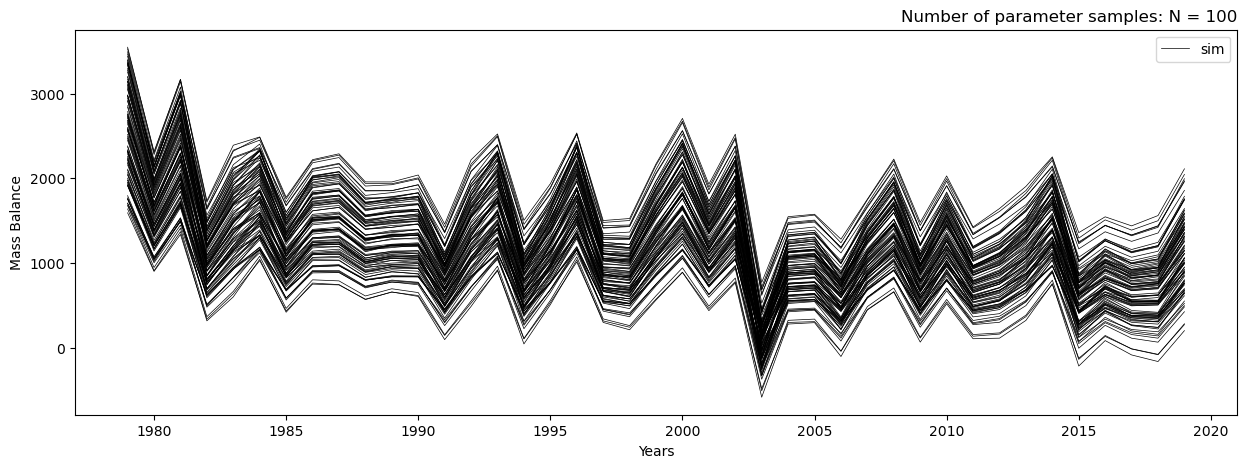

In [60]:
# Plot Monte Carlo (MC) simulations results for the Runoff and compare with data:
plt.figure(figsize=[15,5])
for j in range(mass_balance_sim.shape[0]):
    plt.plot(mbdf.index.values, mass_balance_sim[j], linewidth = 0.5, color = 'k')
# plt.plot(mbdf.index.values, np.transpose(mass_balance_sim), 'k', linewidth = 0.5)
plt.ylabel('Mass Balance'); plt.xlabel('Years')
plt.legend(['sim'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()

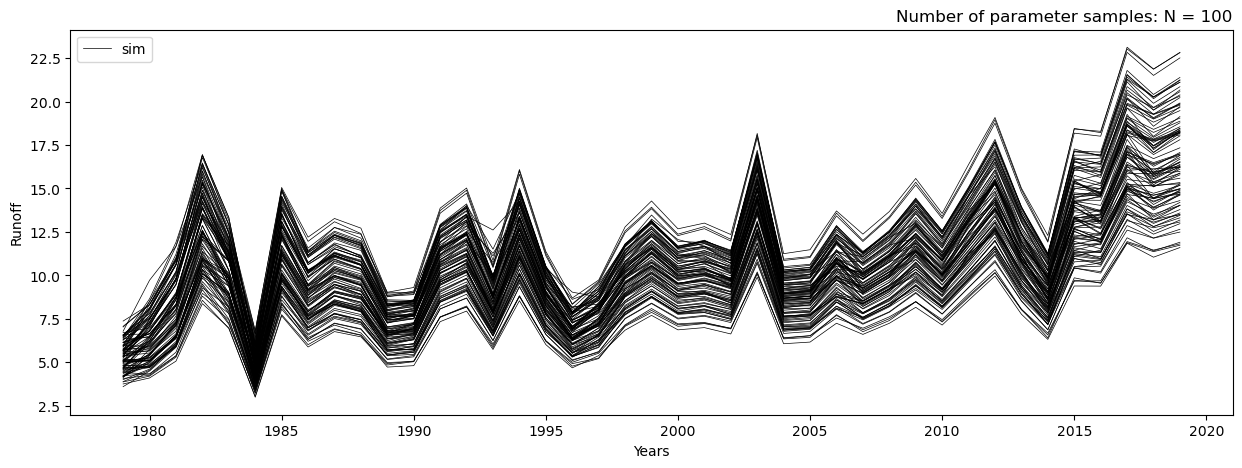

In [61]:
# Plot Monte Carlo (MC) simulations results for the Runoff and compare with data:
plt.figure(figsize=[15,5])
for j in range(runoff_sim.shape[0]):
    plt.plot(mbdf.index.values, runoff_sim[j], linewidth = 0.5, color ='k')
# plt.plot(mbdf.index.values, np.transpose(runoff_sim), 'k', linewidth = 0.5)
plt.ylabel('Runoff'); plt.xlabel('Years')
plt.legend(['sim'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()

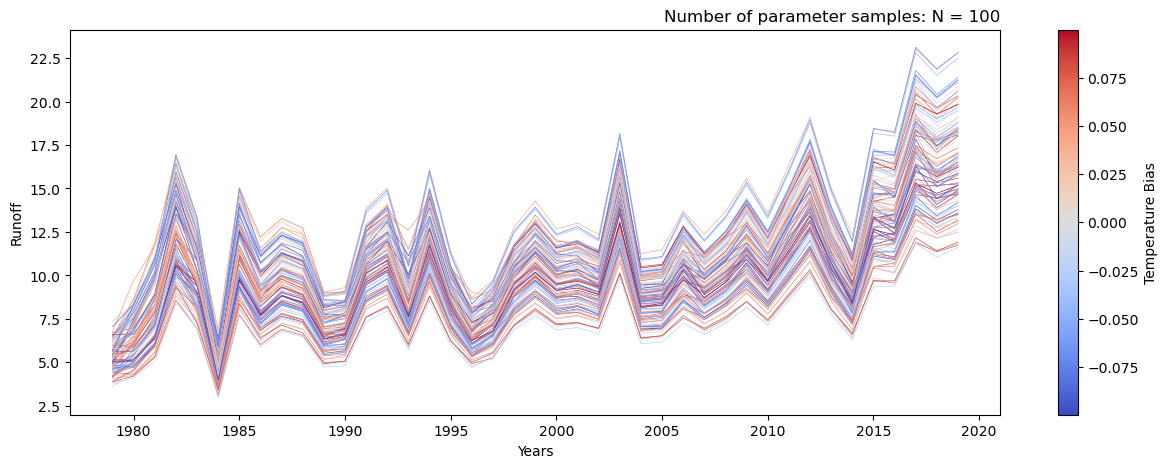

In [62]:
# Also colour mapping (retrospectively) based on temp_bias values
import matplotlib.pyplot as plt
import numpy as np

temp_bias_index = 2  # Index of temp_bias in X

import matplotlib.pyplot as plt
import numpy as np

# Colormap and normalization
cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=X[:, temp_bias_index].min(), vmax=X[:, temp_bias_index].max())

fig, ax = plt.subplots(figsize=(15, 5))

# Plot each simulation with color based on temp_bias
for i in range(len(runoff_sim)):  # assuming QQ_runoff is (N, time)
    color = cmap(norm(X[i, temp_bias_index]))
    ax.plot(mbdf.index.values, runoff_sim[i], linewidth=0.5, color=color)

ax.set_ylabel('Runoff')
ax.set_xlabel('Years')
ax.set_title(f"Number of parameter samples: N = {N}", loc='right')

# Add colorbar linked to the same colormap
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Temperature Bias')

plt.show()

In [86]:
YY_hydro = hydro_output_metric_calculator(runoff_sim)

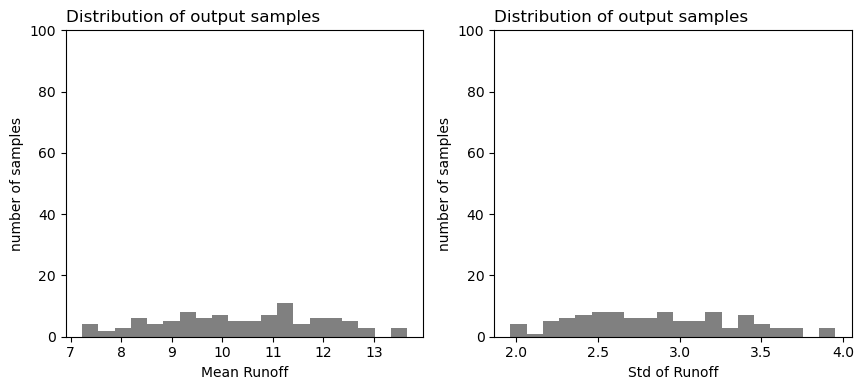

In [65]:
Y_lab_runoff_dist = ['Mean Runoff', 'Std of Runoff']

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_hydro[:,0], bins=20, color='grey');
plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_lab_runoff_dist[0])

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_hydro[:,1], bins=20, color='grey');
plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_lab_runoff_dist[1])

plt.tight_layout()

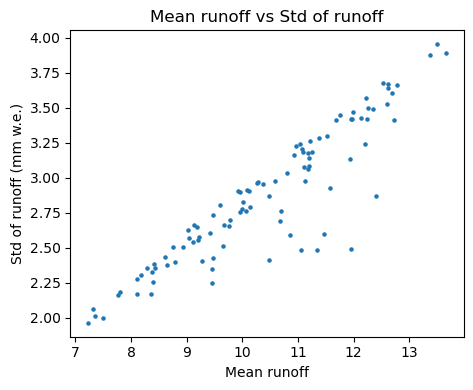

In [66]:
plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(YY_hydro[:,0], YY_hydro[:,1], s=5), plt.title('Mean runoff vs Std of runoff'), plt.xlabel('Mean runoff'), plt.ylabel('Std of runoff (mm w.e.)'),

plt.tight_layout()
plt.show()


In [ ]:
Y_Labels = ['Mean Runoff', 'Std of Runoff']

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        plt.plot(X[:, i], YY_hydro[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       
    plt.show()

interact(scatter_function,  metric = Y_Labels);

interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

In [ ]:
temp_bias_index = 2

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], YY_hydro[:, j], c=X[:, temp_bias_index], cmap='coolwarm', edgecolors='grey')
        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Temp Bias (°C)')
    plt.show()

interact(scatter_function, metric=Y_Labels);


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

# Quantitative sensitivity: RSA with bootstrapping

Note: This is currently an abitrary threshold in which we can update if we obtain the desired values. I have put 25, this is the runoff standard deviation and mean value in Megatonnes per year. 

The RSA sensitivity analysis may be incorrect due to considering an arbitrary threshold, but this is an example of how the RSA can be used in this notebook with the OGGM runoff output.

If we obtain the correct values we can add this into our code easily.

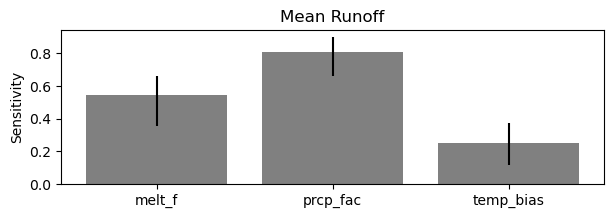

/home/chloe/micromamba/envs/oggm_env/lib/python3.11/site-packages/safepython/RSA_thres.py:303: UserWarning: Cannot find any output value below the threshold! Try increasing the threshold value
  warn('Cannot find any output value below the threshold! Try increasing the threshold value')
/home/chloe/micromamba/envs/oggm_env/lib/python3.11/site-packages/safepython/util.py:337: UserWarning: Statistics were computed using 41 bootstrap resamples instead of 50
  warn('Statistics were computed using ' + '%d' % (np.sum(idx))+


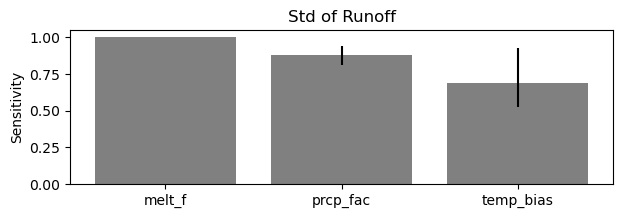

In [ ]:
Nboot = 50 # Number of resamples used for bootstrapping
# TODO: Currently, I am not sure if we have observed hydro data for the runoff to set targets against?
# For now, we can just set some arbitrary target values to see the sensitivity indices
#  When we know what we are doing this will need to be updated - i.e. glacier we are investigating, questions we want to answer etc.
for i in range(2):
    if i==0:
        Y=YY_hydro[:,0]
        target=10 # placeholder target
    if i==1:
        Y=YY_hydro[:,1] # placeholder targer
        target=2

    # plot:
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_labels), plt.ylabel('Sensitivity')
    plt.show()

## The relationship of temp_bias with the other parameters.

After investigating the scatter plots and the tight correlations of temperature bias, we can assume this will be the dominating factor in our sensitivity analysis. We can investigate the relationship between the temp_bias and the other parameters on our plot with a colour mapping.

In [53]:
def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], X[:, i-1], 
                         c=YY_hydro[:, j], cmap='coolwarm', edgecolors='grey')
        
        plt.ylabel(X_labels[i-1])    
        plt.xlabel(X_labels[i])      

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Mean Runoff (Mt)')
    plt.show()

interact(scatter_function, metric=Y_Labels);


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

## Investigating the relationship between parameters and the runoff

Here we will be plotting a combination of all the parameters we are investigating sensitivity for in a scatter plot, and colour-mapping the points by the values of the output metrics.

We have investigated sensitivity above, but this will allow us to investigate relationships of pairs of parameters in a bit more detail with the outputs of the runoff (both the mean of the runoff and the standard deviation of the runoff). 

In [304]:
def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], X[:, i-1], 
                         c=YY_hydro[:, j], cmap='coolwarm', edgecolors='grey')
        
        plt.ylabel(X_labels[i-1])    
        plt.xlabel(X_labels[i])      

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Mean Runoff (Mt)')
    plt.show()

interact(scatter_function, metric=Y_Labels);


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

## PAWN Sensitivity Analysis

Above, for the Global Sensitivity Analysis we have used only RSA with bootstapping as our sensitivity analysis technique. 

As we have discussed, RSA requires a target value to differentiate between "behavioural" and "non-behavioural", which will reflect the sensitivities of our parameters. For runoff, as previously stated, we do not have an obvious metric to compare our data to. So we will investigate the use of another method in which we don't need this target value.

We will now move onto the PAWN technique to try another method of Sensitivity Analysis in the SAFE Toolbox that does not require a target value.

In [ ]:
import safepython.plot_functions as pf # Module to visualize the results
# Define interactive visualisation function to calculate and visualise sensitivity indices
# for the chosen output metric and different choices of the PAWN tuning parameters (n,Nboot,aggr)

def pawn_function(metric='Mean Runoff', n = 5, aggr = 'median', Nboot = 500):
    # Extract output metric:
    if metric == 'Mean Runoff':
        i = 0
    elif metric == 'Std of Runoff':
        i = 1   
    Y = YY_hydro[:, i]; 

    X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
    
    # Apply PAWN
    # Tuning parameters:
    # n = number of conditioning intervals
    # aggr = statistic to aggregate KS values
    # Nboot = number of bootstrapping resamples used to derive confidence bounds of sensitivity indices   

    # Compute sensitivity indices for Nboot bootstrap resamples
    KS_median, KS_mean, KS_max = PAWN.pawn_indices(X, Y, n, Nboot=Nboot)
    # KS_median and KS_mean and KS_max have shape (Nboot, M)
        
    # Compute mean and confidence intervals of the sensitivity indices across the bootstrap resamples:
    KS_median_m, KS_median_lb, KS_median_ub = aggregate_boot(KS_median) # shape (M,)
    KS_mean_m, KS_mean_lb, KS_mean_ub = aggregate_boot(KS_mean) # shape (M,)
    KS_max_m, KS_max_lb, KS_max_ub = aggregate_boot(KS_max) # shape (M,)

    # Plot sensitivity indices:
    plt.figure()
    plt.title("Output metric = %s" % metric)
    if aggr == 'median':
        pf.boxplot1(KS_median_m, S_lb=KS_median_lb, S_ub=KS_median_ub, X_Labels=X_labels, Y_Label='sensitivity (median KS)')
    if aggr == 'mean':
        pf.boxplot1(KS_mean_m, S_lb=KS_mean_lb, S_ub=KS_mean_ub, X_Labels=X_labels, Y_Label='sensitivity (mean KS)')
    if aggr == 'max':
        pf.boxplot1(KS_max_m, S_lb=KS_max_lb, S_ub=KS_max_ub, X_Labels=X_labels, Y_Label='sensitivity (max KS)')
    plt.show()

interact(pawn_function, metric = ['Mean Runoff','Std of Runoff'], n = (2, 20, 1), aggr = ['median', 'mean','max'], Nboot = (0, 500, 10));


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…